## Adversarial training

In [12]:
import torch
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt
import numpy as np

torch.manual_seed(0)

device = torch.device(
    "cuda" if torch.cuda.is_available()
    else "mps" if torch.backends.mps.is_available()
    else "cpu"
)
print(device)

mps


Training STANDARD model...
Training ADVERSARIAL model...

Test MSE:
Standard (clean):       0.1477
Adversarial (clean):    0.0934
Standard (attacked):    0.3588
Adversarial (attacked): 0.2358


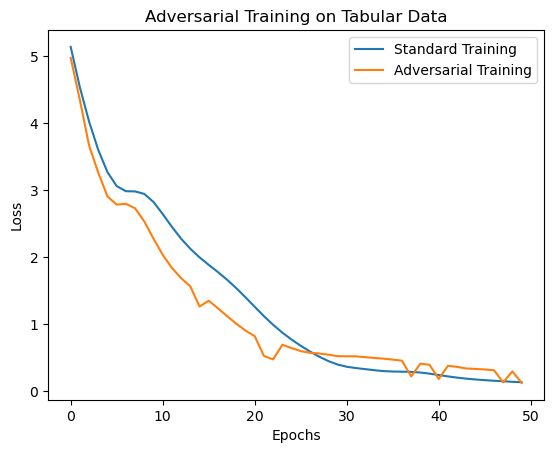

In [16]:


# -------------------------
# 1. Generate tabular data
# -------------------------
N = 100
X = torch.randn(N, 2)

# Nonlinear target
y = (X[:, 0]**2 + torch.sin(X[:, 1]) + 0.1 * torch.randn(N)).unsqueeze(1)

X=X.to(device)
y=y.to(device)
Ntr=int(N/2)
# Train / test split
X_train, X_test = X[:Ntr], X[Ntr:]
y_train, y_test = y[:Ntr], y[Ntr:]

# -------------------------
# 2. Simple model
# -------------------------
class Net(nn.Module):
    def __init__(self):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(2, 32),
            nn.ReLU(),
            nn.Linear(32, 32),
            nn.ReLU(),
            nn.Linear(32, 1)
        )

    def forward(self, x):
        return self.net(x)

# -------------------------
# 3. FGSM attack
# -------------------------
def fgsm_attack(model, x, y, epsilon=0.1):
    x_adv = x.clone().detach().requires_grad_(True)

    criterion = nn.MSELoss()
    output = model(x_adv)
    loss = criterion(output, y)

    loss.backward()

    # perturb in gradient direction
    x_adv = x_adv + epsilon * x_adv.grad.sign()
    return x_adv.detach()

# -------------------------
# 4. Train functions
# -------------------------
def train(model, adversarial=False, epochs=50):
    optimizer = optim.Adam(model.parameters(), lr=0.01)
    criterion = nn.MSELoss()

    losses = []

    for _ in range(epochs):
        optimizer.zero_grad()

        x = X_train
        y_true = y_train

        if adversarial and np.random.rand()<0.85:
            x = fgsm_attack(model, x, y_true)

        out = model(x)
        loss = criterion(out, y_true)

        loss.backward()
        optimizer.step()

        losses.append(loss.item())

    return losses

def evaluate(model, x, y):
    with torch.no_grad():
        return nn.MSELoss()(model(x), y).item()

# -------------------------
# 5. Train models
# -------------------------
model_standard = Net().to(device)
model_adv = Net().to(device)

print("Training STANDARD model...")
loss_std = train(model_standard, adversarial=False)

print("Training ADVERSARIAL model...")
loss_adv = train(model_adv, adversarial=True)

# -------------------------
# 6. Evaluate robustness
# -------------------------
# clean test
clean_std = evaluate(model_standard, X_test, y_test)
clean_adv = evaluate(model_adv, X_test, y_test)

# adversarial test
X_test_adv = fgsm_attack(model_standard, X_test, y_test)

adv_std = evaluate(model_standard, X_test_adv, y_test)
adv_adv = evaluate(model_adv, X_test_adv, y_test)

# -------------------------
# 7. Results
# -------------------------
print("\nTest MSE:")
print(f"Standard (clean):       {clean_std:.4f}")
print(f"Adversarial (clean):    {clean_adv:.4f}")
print(f"Standard (attacked):    {adv_std:.4f}")
print(f"Adversarial (attacked): {adv_adv:.4f}")

# -------------------------
# 8. Plot
# -------------------------
plt.plot(loss_std, label="Standard Training")
plt.plot(loss_adv, label="Adversarial Training")

plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.title("Adversarial Training on Tabular Data")
plt.legend()

plt.show()